#Dataset:
###Files and images directories

In [ ]:
# Upload kaggle.json
from google.colab import files
files.upload()  # Choose the kaggle.json file

# Make a directory and move the file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

# Change permissions
!chmod 600 ~/.kaggle/kaggle.json

# Example: Download a dataset
!kaggle datasets download -d "orvile/brain-cancer-mri-dataset"
# Unzip the dataset
#!unzip dataset-name.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/orvile/brain-cancer-mri-dataset
License(s): CC-BY-SA-4.0


In [ ]:
!unzip brain-cancer-mri-dataset.zip

In [ ]:
#Folder of image types:
!ls Brain_Cancer\ raw\ MRI\ data/Brain_Cancer

brain_glioma  brain_menin  brain_tumor


#Dataset path:

In [ ]:
#Path:
dataset_path ="/content/Brain_Cancer raw MRI data/Brain_Cancer"
class_labels = ['brain_glioma', 'brain_menin', 'brain_tumor']

#Libraries:

In [ ]:
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNetV2

#Images from Brain Tumor:

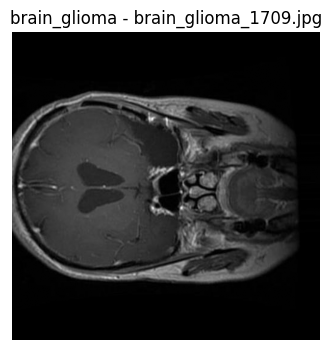

(512, 512)


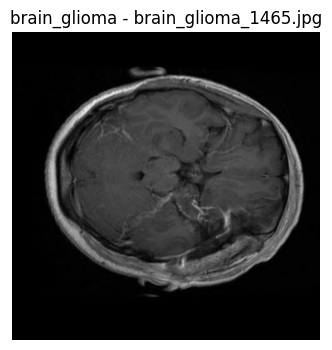

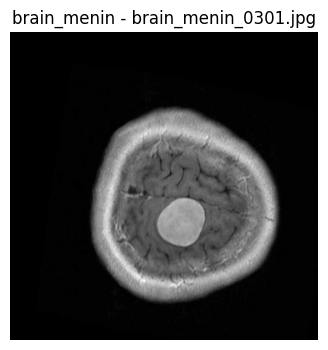

(512, 512)


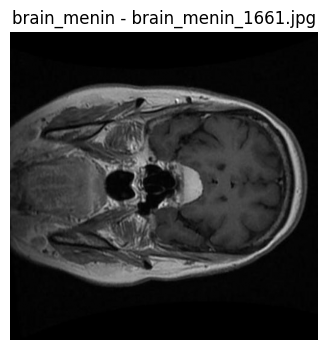

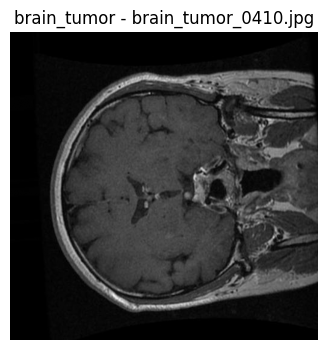

(512, 512)


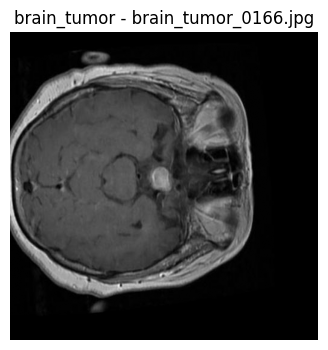

In [ ]:
#Show 2 images per class label:
for class_name in class_labels:
    class_path = os.path.join(dataset_path, class_name)#Labelled folder containing img
    image_files = os.listdir(class_path)#List of img

    shown = 0
    for file in image_files:
        img_path = os.path.join(class_path, file)#Path of img file

        #Load image in grayscale mode, '0' specifies cv2.IMREAD_GRAYSCALE:
        img = cv2.imread(img_path, 0)
        #If file is not an image:
        if img is None:
            print(f"Skipping invalid image: {img_path}")
            continue

        #Show image:
        plt.figure(figsize=(4, 4))
        plt.imshow(img, cmap='gray')
        plt.title(f"{class_name} - {file}")
        plt.axis('off')
        plt.show()

        shown += 1
        if shown >= 2:
            break
        print(img.shape)

#Pipeline:

##Load and Preprocess images:

In [ ]:
X,y=[],[]#Image data, class labels

for label_index, label in enumerate(class_labels):
    folder = os.path.join(dataset_path, label)#Folder containing img, eg. brain_tumor
    for file in os.listdir(folder):#List of folders
        file_path = os.path.join(folder, file)#List of img in folders
        img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)#Img from path

        if img is None:
            print(f"Skipping invalid image: {file}")
            continue

        #Resize img and normalize pixels [0,256] to [0,1]:
        img = cv2.resize(img, (128,128))
        img = img / 255.0

        X.append(img)
        y.append(label_index)# 0, 1, or 2

#Convert to NumPy arrays
X = np.array(X).reshape(-1, 128, 128, 1)  #Add channel dimension
y = np.array(y)

##Train test split

In [ ]:
#Stratify=y ensures data is split 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(4844, 128, 128, 1) (1212, 128, 128, 1) (4844,) (1212,)


##Model:

In [ ]:
model=models.Sequential([
    #Resized img is 128,128 and channels=1 (greyscale)
    layers.Input(shape=(128,128,1)),
    #Convolution to extract spatial features, 32 kernels or learnable filters size 3x3, Activation for Non linearity
    layers.Conv2D(32, (3,3), activation='relu'),
    #Batch Normalization adjusts inputs for better training
    layers.BatchNormalization(),
    #Maxpooling reduces memory, size and volume, faster computation, prevents overfitting
    layers.MaxPooling2D(2,2),
    #Dropout - Probablilty of Neuron being randomly set to zero
    layers.Dropout(0.3),

    layers.Conv2D(64, (3,3), activation='relu'),#64 filters, 3x3
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.3),

    layers.Flatten(),#Flatten inputs
    #Every neuron in layer is connected to every neuron in previous layer
    layers.Dense(64, activation='relu'),#Deeply connected layer, 64 units
    #For Dense, dropout = 50%
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax')#3 classes

])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,705,859 (14.14 MB)

 Trainable params: 3,705,667 (14.14 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
#Early stopping:
early_stop = EarlyStopping(
    monitor='val_loss',     #Watch: validation loss
    patience=3,             #Stop if val_loss doesn't improve after 3 epochs
    restore_best_weights=True #Revert to best weights
)

In [ ]:
#Fitting model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=32, callbacks=[early_stop])

Epoch 1/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 185s 1s/step - accuracy: 0.5228 - loss: 2.6107 - val_accuracy: 0.3309 - val_loss: 49.3757
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 205s 1s/step - accuracy: 0.5756 - loss: 0.8703 - val_accuracy: 0.3309 - val_loss: 36.8464
Epoch 3/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 191s 1s/step - accuracy: 0.6010 - loss: 0.8288 - val_accuracy: 0.4992 - val_loss: 9.1219
Epoch 4/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - accuracy: 0.6271 - loss: 0.8192 - val_accuracy: 0.5611 - val_loss: 1.2796
Epoch 5/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 212s 1s/step - accuracy: 0.6575 - loss: 0.7751 - val_accuracy: 0.5916 - val_loss: 1.1017
Epoch 6/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 195s 1s/step - accuracy: 0.6801 - loss: 0.7518 - val_accuracy: 0.6254 - val_loss: 1.0759
Epoch 7/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - accuracy: 0.6912 - loss: 0.7284 - val_accuracy: 0.7294 - val_loss: 0.7173
Epoch 8/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.7169 - loss: 0.6791 - val_ac

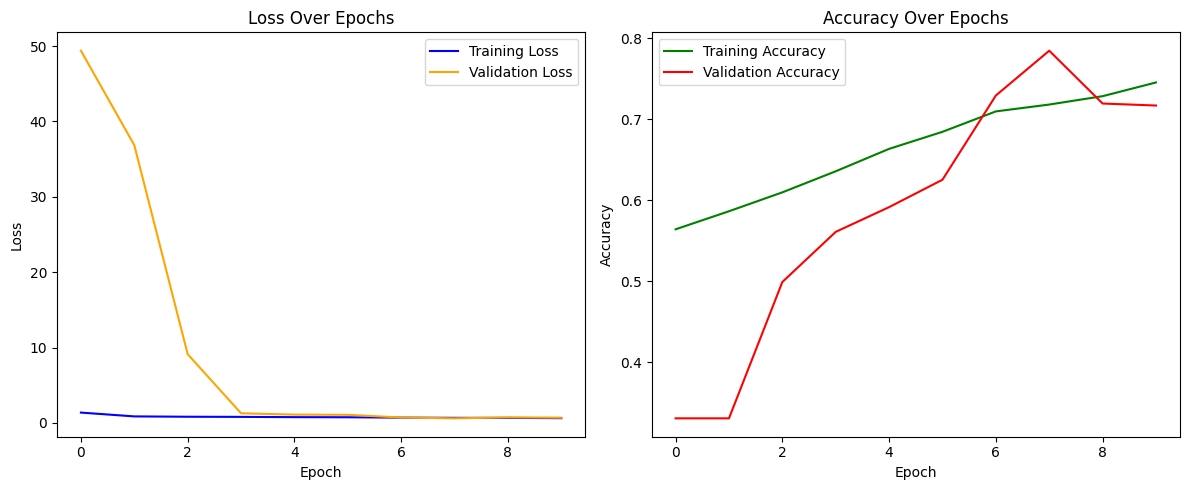

In [ ]:
#Plotting loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label="Training Loss", color='blue')
plt.plot(history.history['val_loss'], label="Validation Loss", color='orange')
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

#Plotting accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label="Training Accuracy", color='green')
plt.plot(history.history['val_accuracy'], label="Validation Accuracy", color='red')
plt.title("Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 200ms/step - accuracy: 0.7897 - loss: 0.5894
Test Accuracy: 78.47%


#Pretrained model MobileNetV2:

In [ ]:
base_model = MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights='imagenet')
base_model.trainable = False  #Freeze base

new_model = models.Sequential([
    layers.Resizing(128, 128),  # f your images are grayscale, convert them to 3 channels
    layers.Conv2D(3, (3, 3), padding='same'),  #To make grayscale to RGB
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax')
])
new_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [ ]:
#Fitting model
new_history = new_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=32, callbacks=[early_stop])

Epoch 1/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step - accuracy: 0.8024 - loss: 0.4788 - val_accuracy: 0.8944 - val_loss: 0.2752
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - accuracy: 0.8995 - loss: 0.2605 - val_accuracy: 0.8738 - val_loss: 0.3096
Epoch 3/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.9189 - loss: 0.2120 - val_accuracy: 0.9175 - val_loss: 0.2093
Epoch 4/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step - accuracy: 0.9363 - loss: 0.1693 - val_accuracy: 0.9224 - val_loss: 0.1913
Epoch 5/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 151s 996ms/step - accuracy: 0.9501 - loss: 0.1362 - val_accuracy: 0.9018 - val_loss: 0.2478
Epoch 6/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 202s 1000ms/step - accuracy: 0.9443 - loss: 0.1452 - val_accuracy: 0.9315 - val_loss: 0.1822
Epoch 7/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 198s 971ms/step - accuracy: 0.9588 - loss: 0.1158 - val_accuracy: 0.9332 - val_loss: 0.1758
Epoch 8/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 151s 992ms/step - accuracy: 0.9725 - loss: 0.08

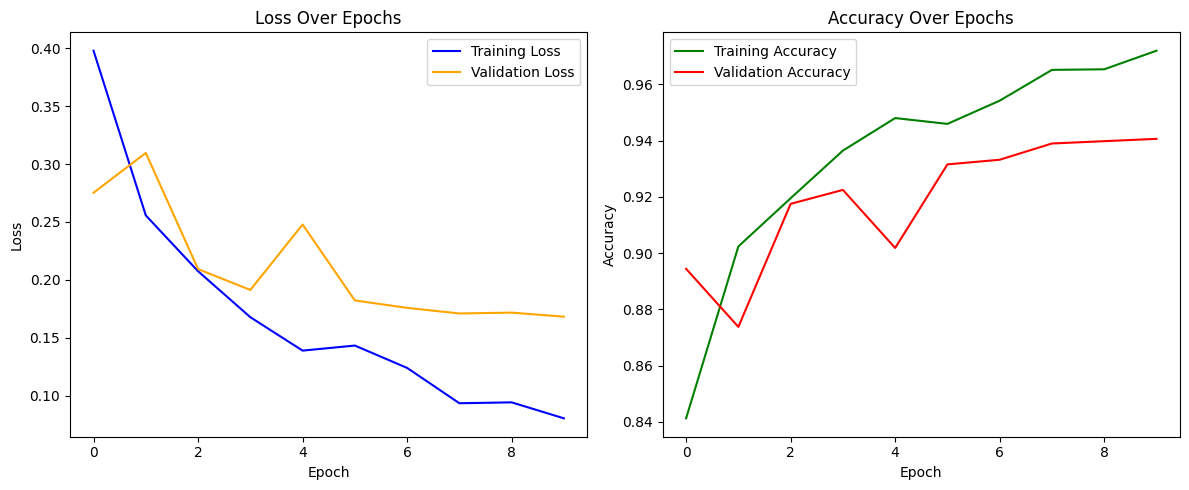

In [ ]:
#Plotting loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(new_history.history['loss'], label="Training Loss", color='blue')
plt.plot(new_history.history['val_loss'], label="Validation Loss", color='orange')
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

#Plotting accuracy
plt.subplot(1, 2, 2)
plt.plot(new_history.history['accuracy'], label="Training Accuracy", color='green')
plt.plot(new_history.history['val_accuracy'], label="Validation Accuracy", color='red')
plt.title("Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
test_loss, test_acc = new_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

38/38 ━━━━━━━━━━━━━━━━━━━━ 15s 382ms/step - accuracy: 0.9416 - loss: 0.1560
Test Accuracy: 94.06%


Old model accuracy : 78.47%
New - 94.06%

In [ ]:
new_model.save("brain_mri_mobilenetv2.keras")